In [1]:
from module import *

In [6]:
daily_activity = pd.read_sql("SELECT * FROM daily_activity", conn)
daily_activity['Id'] = daily_activity['Id'].astype(int).astype(str)
daily_activity['ActivityDate'] = daily_activity['ActivityDate'].apply(pd.to_datetime)
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [8]:
daily_activity.describe().T

,count,mean,min,25%,50%,75%,max,std
ActivityDate,457,2016-04-04 04:40:26.258205,2016-03-12 00:00:00,2016-04-02 00:00:00,2016-04-05 00:00:00,2016-04-08 00:00:00,2016-04-12 00:00:00,NaN
TotalSteps,457.0,6546.562363,0.0,1988.0,5986.0,10198.0,28497.0,5398.493064
TotalDistance,457.0,4.663523,0.0,1.41,4.09,7.16,27.530001,4.082072
TrackerDistance,457.0,4.609847,0.0,1.28,4.09,7.11,27.530001,4.06854
LoggedActivitiesDistance,457.0,0.179427,0.0,0.0,0.0,0.0,6.727057,0.849232
VeryActiveDistance,457.0,1.180897,0.0,0.0,0.0,1.31,21.92,2.487159
ModeratelyActiveDistance,457.0,0.478643,0.0,0.0,0.02,0.67,6.4,0.830995
LightActiveDistance,457.0,2.890197,0.0,0.87,2.93,4.46,12.51,2.237523
SedentaryActiveDistance,457.0,0.001904,0.0,0.0,0.0,0.0,0.1,0.008487
VeryActiveMinutes,457.0,16.623632,0.0,0.0,0.0,25.0,202.0,28.919704


In [24]:
daily_activity['Id'].nunique()

35

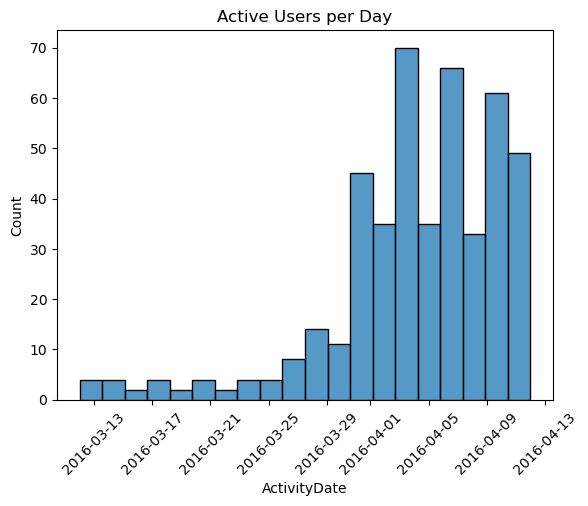

In [9]:
sns.histplot(daily_activity, x='ActivityDate')
plt.xticks(rotation=45)
plt.title("Active Users per Day")
plt.show()

Errors between sum of active distances & total distance

In [53]:
active_distance = daily_activity.filter(like="ActiveDistance")
diff = active_distance.sum(axis=1) - daily_activity['TotalDistance']
diff.abs().describe()

count    4.570000e+02
mean     1.134574e-01
std      7.222709e-01
min      0.000000e+00
25%      0.000000e+00
50%      6.705523e-08
75%      9.999990e-03
max      7.410000e+00
dtype: float64

<Axes: ylabel='Count'>

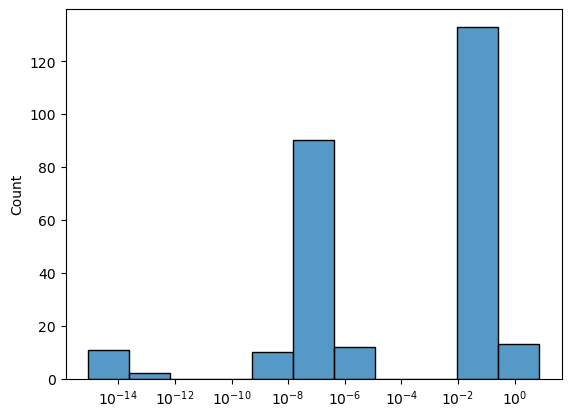

In [60]:
sns.histplot(diff.abs(), log_scale=True)

In [61]:
active_distance.div(daily_activity['TotalDistance'], axis=0).describe()

,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance
count,394.000000,394.000000,394.000000,394.000000
mean,0.152423,0.081993,0.732282,0.000521
std,0.212962,0.126938,0.286266,0.002029
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.509985,0.000000
50%,0.024595,0.035301,0.828102,0.000000
75%,0.278624,0.112288,1.000000,0.000000
max,1.000000,0.891234,1.000000,0.015000


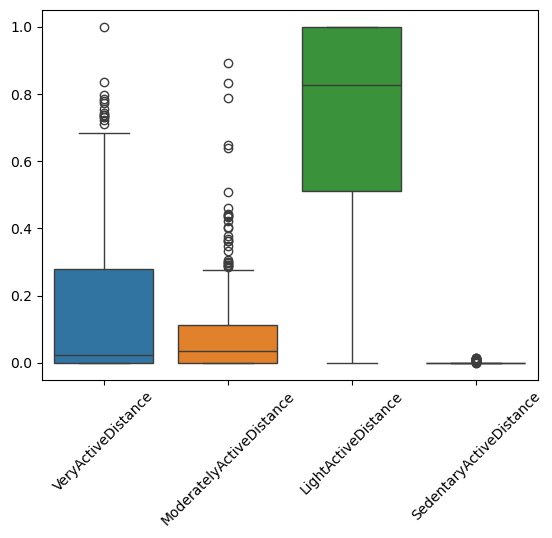

In [65]:
active_distance_fracs = active_distance.div(daily_activity['TotalDistance'], axis=0)
sns.boxplot(active_distance_fracs)
plt.xticks(rotation=45)
plt.show()